### 1. Imports + Preprocess + Core utils

In [3]:
import warnings

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from sklearn.metrics import cohen_kappa_score

warnings.filterwarnings("ignore")


TASKS = ["HP", "Neutrophil", "Mononuclear", "Atrophy", "IM"]


def time_to_seconds(t) -> float | None:
    """Convert 'h:mm:ss' or 'm:ss' to seconds. Returns None if parsing fails."""
    if pd.isna(t):
        return None
    try:
        parts = [int(p) for p in str(t).split(":")]
        if len(parts) == 3:
            h, m, s = parts
            return h * 3600 + m * 60 + s
        if len(parts) == 2:
            m, s = parts
            return m * 60 + s
        return None
    except Exception:
        return None


def parse_diagnosis_code(df: pd.DataFrame, code_col: str = "Diagnosis") -> pd.DataFrame:
    """Split 5-digit diagnosis code into per-task integer columns."""
    df = df.copy()
    df[code_col] = df[code_col].astype(str).str.zfill(5)
    for i, feat in enumerate(TASKS):
        df[feat] = df[code_col].str[i].apply(lambda x: int(x) if str(x).isdigit() else 0)
    return df


def load_rater_file(filepath: str) -> pd.DataFrame:
    """
    Load rater txt/csv-like file with 3 columns:
      Slide_Name, Diagnosis, Time
    """
    df = pd.read_csv(
        filepath,
        sep=",",
        header=None,
        names=["Slide_Name", "Diagnosis", "Time"],
        dtype={"Diagnosis": str},
    )
    df["Time_Seconds"] = df["Time"].apply(time_to_seconds)
    df = parse_diagnosis_code(df, code_col="Diagnosis")
    df = df.dropna(subset=["Time_Seconds"]).reset_index(drop=True)
    return df


def load_all_raters(paths: dict) -> dict:
    """
    paths example:
      {
        "p1_pre": "../washout crossover study/data/pathologist1_pre.txt",
        "p1_post": "../washout crossover study/data/pathologist1_post.txt",
        "p2_pre": "../washout crossover study/data/pathologist2_pre.txt",
        "p2_post": "../washout crossover study/data/pathologist2_post.txt",
      }
    """
    return {k: load_rater_file(v) for k, v in paths.items()}


def bootstrap_mean_kappa(df_a: pd.DataFrame, df_b: pd.DataFrame, n_boot: int = 1000, seed: int = 0):
    """
    Slide-level bootstrap of mean task kappa (quadratic).
    Returns: mean, (ci_low, ci_high), std
    """
    merged = pd.merge(df_a, df_b, on="Slide_Name", suffixes=("_A", "_B"))
    rng = np.random.default_rng(seed)

    boot = []
    for _ in range(n_boot):
        sample = merged.sample(frac=1, replace=True, random_state=int(rng.integers(0, 2**32 - 1)))
        kappas = [
            cohen_kappa_score(sample[f"{t}_A"], sample[f"{t}_B"], weights="quadratic")
            for t in TASKS
        ]
        boot.append(float(np.mean(kappas)))

    boot = np.asarray(boot, dtype=float)
    mean_k = float(boot.mean())
    std_k = float(boot.std(ddof=1))
    ci_low, ci_high = np.percentile(boot, [2.5, 97.5]).tolist()
    return mean_k, (float(ci_low), float(ci_high)), std_k


def lmm_pvalue_paired_time(pre_df: pd.DataFrame, post_df: pd.DataFrame):
    """
    Paired slide-level LMM:
      Time ~ Condition (Post vs Pre), random intercept by Slide_Name
    Returns p-value for Post effect.
    """
    merged = pd.merge(
        pre_df[["Slide_Name", "Time_Seconds"]],
        post_df[["Slide_Name", "Time_Seconds"]],
        on="Slide_Name",
        suffixes=("_Pre", "_Post"),
    )

    long_df = pd.melt(
        merged,
        id_vars=["Slide_Name"],
        value_vars=["Time_Seconds_Pre", "Time_Seconds_Post"],
        var_name="Condition",
        value_name="Time",
    )

    model = smf.mixedlm(
        "Time ~ C(Condition, Treatment('Time_Seconds_Pre'))",
        long_df,
        groups=long_df["Slide_Name"],
    ).fit()

    # index 1 corresponds to the Post indicator term
    return float(model.pvalues.iloc[1])


# ---- Load data (edit paths only) ----
paths = {
        "p1_pre": "../washout crossover study/data/pathologist1_pre.txt",
        "p1_post": "../washout crossover study/data/pathologist1_post.txt",
        "p2_pre": "../washout crossover study/data/pathologist2_pre.txt",
        "p2_post": "../washout crossover study/data/pathologist2_post.txt",
      }
dfs = load_all_raters(paths)

# (Optional) quick sanity check: overall agreement
k_pre, (lo_pre, hi_pre), std_pre = bootstrap_mean_kappa(dfs["p1_pre"], dfs["p2_pre"])
k_post, (lo_post, hi_post), std_post = bootstrap_mean_kappa(dfs["p1_post"], dfs["p2_post"])
print(f"Pre-AI mean κ:  {k_pre:.3f} (95% CI {lo_pre:.3f}–{hi_pre:.3f}), STD={std_pre:.3f}")
print(f"Post-AI mean κ: {k_post:.3f} (95% CI {lo_post:.3f}–{hi_post:.3f}), STD={std_post:.3f}")

Pre-AI mean κ:  0.750 (95% CI 0.718–0.781), STD=0.016
Post-AI mean κ: 0.775 (95% CI 0.735–0.813), STD=0.021


### 2. Task-wise kappa (pre vs. post) + bootstrap STD

In [5]:
import numpy as np
import pandas as pd
from sklearn.metrics import cohen_kappa_score


def task_kappa_table(
    pre_a: pd.DataFrame,
    pre_b: pd.DataFrame,
    post_a: pd.DataFrame,
    post_b: pd.DataFrame,
    tasks: list[str],
    n_boot: int = 1000,
    seed: int = 0,
) -> pd.DataFrame:
    merged_pre = pd.merge(pre_a, pre_b, on="Slide_Name", suffixes=("_A", "_B"))
    merged_post = pd.merge(post_a, post_b, on="Slide_Name", suffixes=("_A", "_B"))

    common = np.intersect1d(merged_pre["Slide_Name"].unique(), merged_post["Slide_Name"].unique())
    rng = np.random.default_rng(seed)

    rows = []
    for t in tasks:
        k_pre = cohen_kappa_score(merged_pre[f"{t}_A"], merged_pre[f"{t}_B"], weights="quadratic")
        k_post = cohen_kappa_score(merged_post[f"{t}_A"], merged_post[f"{t}_B"], weights="quadratic")

        pre_boot, post_boot, delta_boot = [], [], []
        for _ in range(n_boot):
            sampled = rng.choice(common, size=len(common), replace=True)

            pre_s = merged_pre[merged_pre["Slide_Name"].isin(sampled)]
            post_s = merged_post[merged_post["Slide_Name"].isin(sampled)]

            kp = cohen_kappa_score(pre_s[f"{t}_A"], pre_s[f"{t}_B"], weights="quadratic")
            kpo = cohen_kappa_score(post_s[f"{t}_A"], post_s[f"{t}_B"], weights="quadratic")

            pre_boot.append(kp)
            post_boot.append(kpo)
            delta_boot.append(kpo - kp)

        pre_boot = np.asarray(pre_boot, float)
        post_boot = np.asarray(post_boot, float)
        delta_boot = np.asarray(delta_boot, float)

        rows.append(
            {
                "Feature": t,
                "Kappa_Pre": float(k_pre),
                "Kappa_Post": float(k_post),
                "Pre_STD": float(pre_boot.std(ddof=1)),
                "Post_STD": float(post_boot.std(ddof=1)),
            }
        )

    return pd.DataFrame(rows)


task_df = task_kappa_table(
    dfs["p1_pre"],
    dfs["p2_pre"],
    dfs["p1_post"],
    dfs["p2_post"],
    tasks=TASKS,
    n_boot=1000,
    seed=0,
)

display(task_df.round(3))

,Feature,Kappa_Pre,Kappa_Post,Pre_STD,Post_STD
0,HP,0.804,0.876,0.023,0.016
1,Neutrophil,0.830,0.847,0.024,0.019
2,Mononuclear,0.454,0.580,0.027,0.032
3,Atrophy,0.772,0.678,0.035,0.057
4,IM,0.902,0.901,0.015,0.015


### 3. Efficiency

In [8]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf


def cohens_d_independent(x: np.ndarray, y: np.ndarray) -> float:
    """Cohen's d using pooled SD (commonly used; fine for reporting)."""
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    pooled = np.sqrt((x.std(ddof=1) ** 2 + y.std(ddof=1) ** 2) / 2)
    return float((x.mean() - y.mean()) / pooled) if pooled > 0 else np.nan


def paired_dz(pre: np.ndarray, post: np.ndarray) -> float:
    """Paired effect size dz = mean(diff) / sd(diff)."""
    diff = np.asarray(pre, float) - np.asarray(post, float)
    sd = diff.std(ddof=1)
    return float(diff.mean() / sd) if sd > 0 else np.nan


def summarize_efficiency(dfs: dict, raters=("p1", "p2")) -> pd.DataFrame:
    rows = []
    combined_blocks = []

    for r in raters:
        pre = dfs[f"{r}_pre"][["Slide_Name", "Time_Seconds"]]
        post = dfs[f"{r}_post"][["Slide_Name", "Time_Seconds"]]
        merged = pd.merge(pre, post, on="Slide_Name", suffixes=("_Pre", "_Post"))

        pre_t = merged["Time_Seconds_Pre"].to_numpy(float)
        post_t = merged["Time_Seconds_Post"].to_numpy(float)

        mean_pre = float(pre_t.mean())
        mean_post = float(post_t.mean())
        reduction_pct = float((mean_pre - mean_post) / mean_pre * 100) if mean_pre > 0 else np.nan

        p_val = lmm_pvalue_paired_time(
            dfs[f"{r}_pre"],
            dfs[f"{r}_post"],
        )

        rows.append(
            {
                "Rater": r.upper(),
                "Mean_Pre": mean_pre,
                "Mean_Post": mean_post,
                "Reduction_%": reduction_pct,
                "LMM_p": p_val,
                "Cohen_d": cohens_d_independent(pre_t, post_t),
                "Paired_dz": paired_dz(pre_t, post_t),
            }
        )

        merged = merged.assign(Rater=r.upper())
        combined_blocks.append(merged)

    all_data = pd.concat(combined_blocks, ignore_index=True)

    # Combined LMM: random intercept by Slide_Name
    long_df = pd.melt(
        all_data,
        id_vars=["Slide_Name", "Rater"],
        value_vars=["Time_Seconds_Pre", "Time_Seconds_Post"],
        var_name="Condition",
        value_name="Time",
    )

    model = smf.mixedlm(
        "Time ~ C(Condition, Treatment('Time_Seconds_Pre'))",
        long_df,
        groups=long_df["Slide_Name"],
    ).fit()

    combined_pre = float(all_data["Time_Seconds_Pre"].mean())
    combined_post = float(all_data["Time_Seconds_Post"].mean())
    combined_reduction = float((combined_pre - combined_post) / combined_pre * 100) if combined_pre > 0 else np.nan
    combined_p = float(model.pvalues.iloc[1])

    rows.append(
        {
            "Rater": "COMBINED",
            "Mean_Pre": combined_pre,
            "Mean_Post": combined_post,
            "Reduction_%": combined_reduction,
            "LMM_p": combined_p,
            "Cohen_d": np.nan,
            "Paired_dz": np.nan,
        }
    )

    return pd.DataFrame(rows)


eff_df = summarize_efficiency(dfs, raters=("p1", "p2"))
display(eff_df)

,Rater,Mean_Pre,Mean_Post,Reduction_%,LMM_p,Cohen_d,Paired_dz
0,P1,51.402985,31.485075,38.748548,3.529785e-17,0.997577,0.728029
1,P2,49.776119,34.992537,29.700150,5.488164e-14,0.831027,0.649606
2,COMBINED,50.589552,33.238806,34.297094,1.019931e-32,NaN,NaN


### 4. Figure 

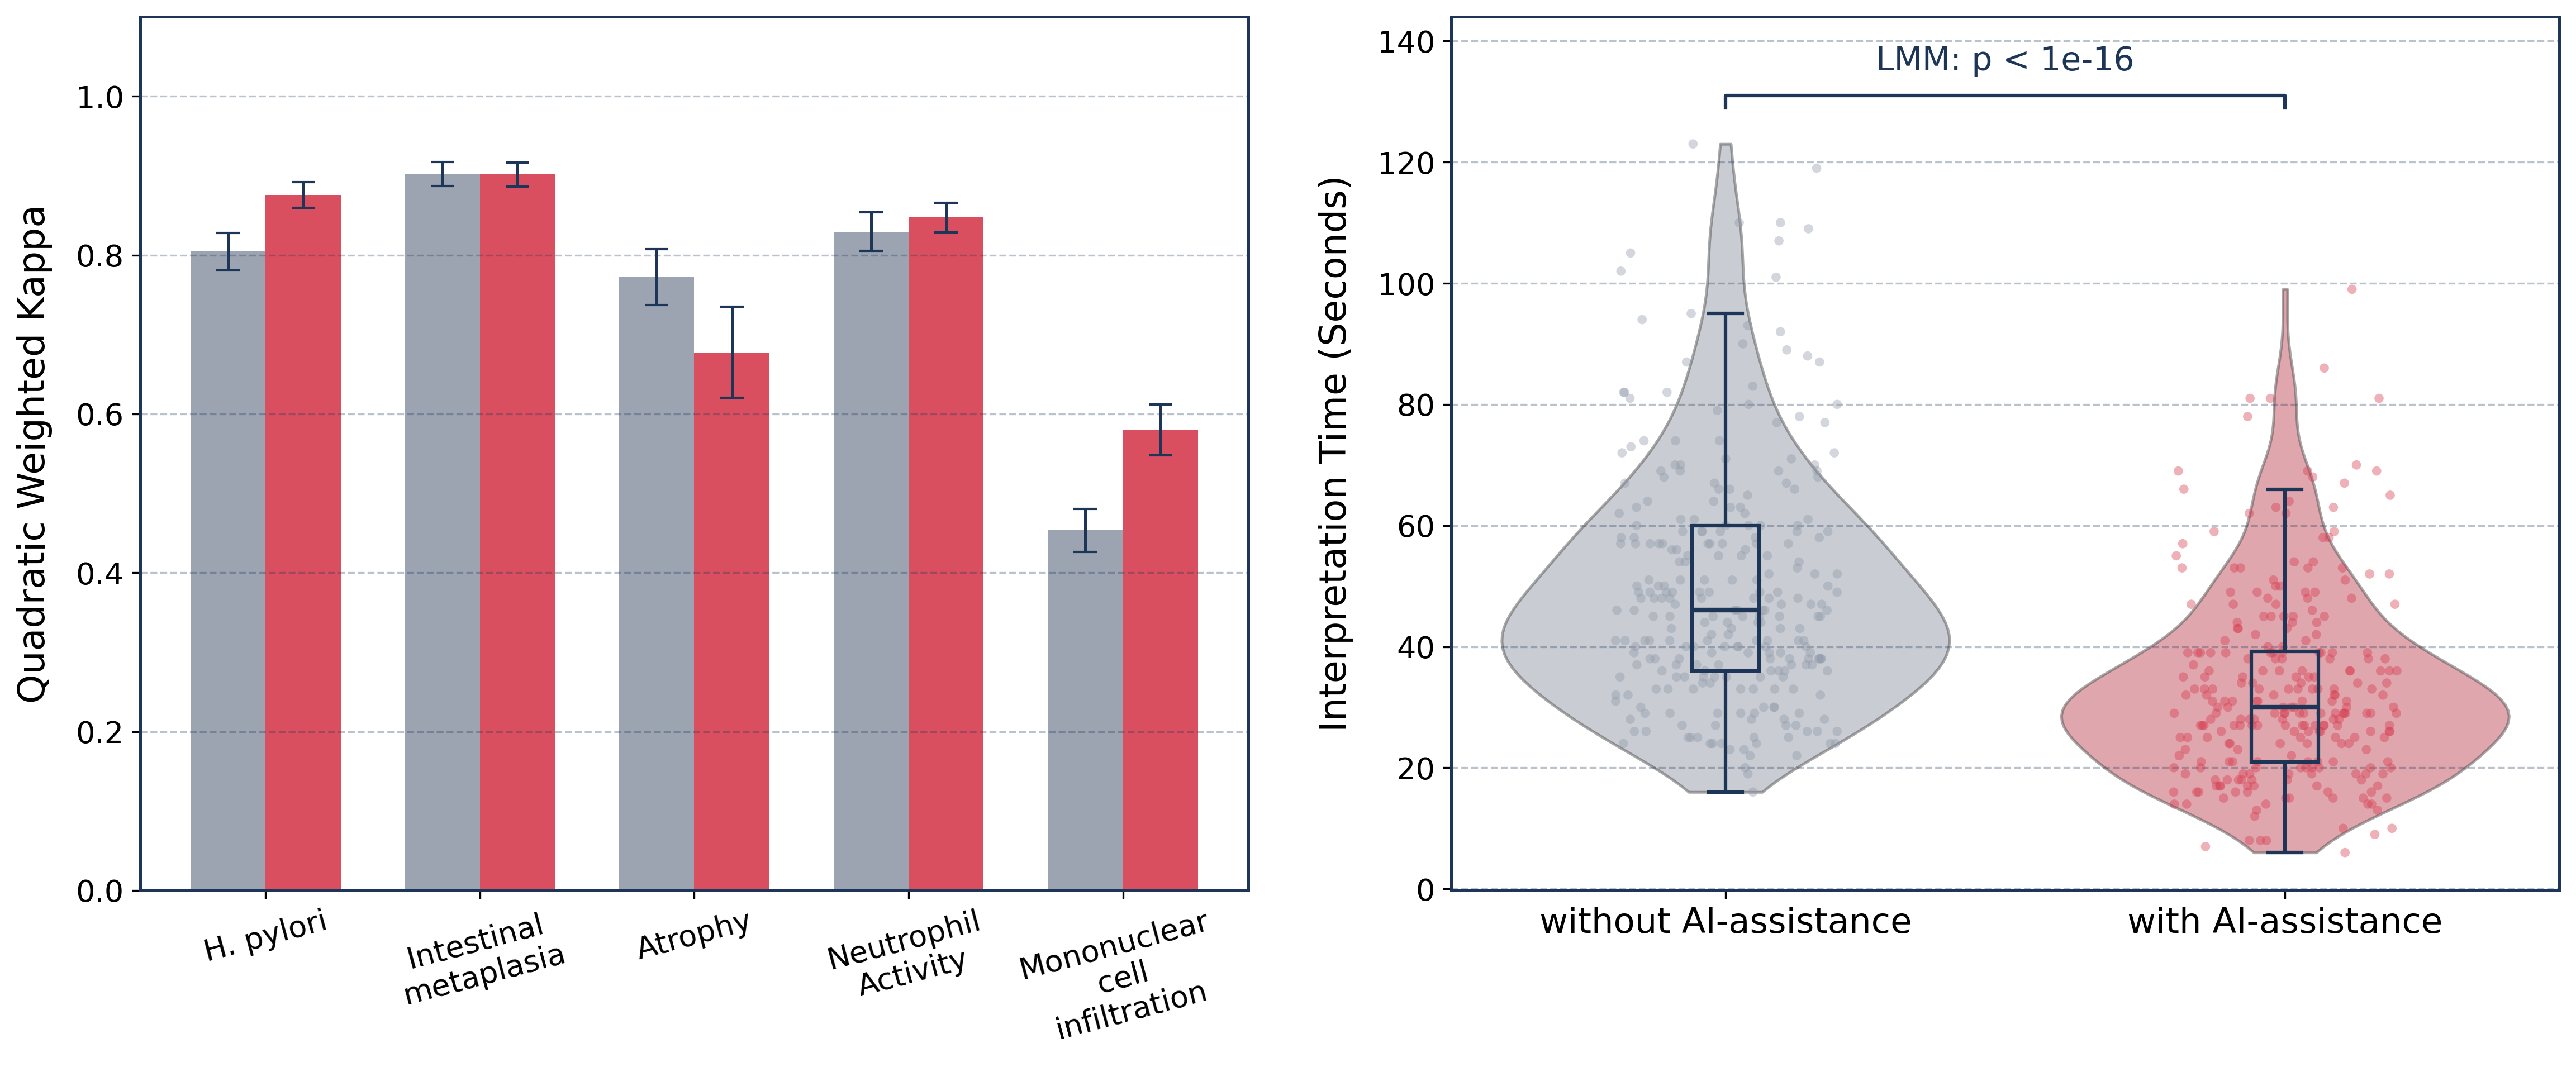

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.edgecolor"] = "#1d3557"
plt.rcParams["axes.linewidth"] = 1.2
plt.rcParams["figure.dpi"] = 300

TASK_DISPLAY_ORDER = ["HP", "IM", "Atrophy", "Neutrophil", "Mononuclear"]
TASK_DISPLAY_LABELS = [
    "H. pylori",
    "Intestinal\nmetaplasia",
    "Atrophy",
    "Neutrophil\nActivity",
    "Mononuclear\ncell\ninfiltration",
]

PALETTE = {"without AI-assistance": "#919aaa", "with AI-assistance": "#d63c4f"}
SPINE_COLOR = "#1d3557"


def _yerr_std(df: pd.DataFrame, prefix: str) -> np.ndarray:
    std = df[f"{prefix}_STD"].to_numpy()
    return np.vstack([std, std])


def _format_axes(ax: plt.Axes, legend_loc: str = "upper right") -> None:
    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color(SPINE_COLOR)

    ax.yaxis.grid(True, linestyle="--", alpha=0.3, color=SPINE_COLOR)
    if ax.get_legend() is not None:
        ax.legend(frameon=False, loc=legend_loc, fontsize=14)


def draw_combined_study_figure(stats_df: pd.DataFrame, dfs: dict) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # --------------------------
    # Panel A: Kappa
    # --------------------------
    ax_kappa = axes[0]
    x = np.arange(len(stats_df))
    width = 0.35

    ax_kappa.bar(
        x - width / 2,
        stats_df["Pre_Kappa"],
        width,
        label="without AI-assistance",
        color=PALETTE["without AI-assistance"],
        yerr=_yerr_std(stats_df, "Pre"),
        capsize=5,
        error_kw={"elinewidth": 1.2, "ecolor": SPINE_COLOR},
        alpha=0.9,
    )
    ax_kappa.bar(
        x + width / 2,
        stats_df["Post_Kappa"],
        width,
        label="with AI-assistance",
        color=PALETTE["with AI-assistance"],
        yerr=_yerr_std(stats_df, "Post"),
        capsize=5,
        error_kw={"elinewidth": 1.2, "ecolor": SPINE_COLOR},
        alpha=0.9,
    )

    ax_kappa.set_ylim(0, 1.1)
    ax_kappa.set_ylabel("Quadratic Weighted Kappa", fontsize=16, labelpad=10)
    ax_kappa.set_xticks(x)
    ax_kappa.set_xticklabels(TASK_DISPLAY_LABELS, fontsize=13, rotation=15)
    ax_kappa.tick_params(axis="y", labelsize=13)

    # --------------------------
    # Panel B: Efficiency (raincloud-style)
    # --------------------------
    ax_eff = axes[1]

    records = []
    for rater in ["p1", "p2"]:
        pre = dfs[f"{rater}_pre"][["Slide_Name", "Time_Seconds"]].copy()
        post = dfs[f"{rater}_post"][["Slide_Name", "Time_Seconds"]].copy()
        pre["Condition"] = "without AI-assistance"
        post["Condition"] = "with AI-assistance"
        records.append(pd.concat([pre, post], ignore_index=True))

    df_eff = pd.concat(records, ignore_index=True)
    df_eff = df_eff[df_eff["Time_Seconds"] < 170]

    sns.violinplot(
        data=df_eff,
        x="Condition",
        y="Time_Seconds",
        ax=ax_eff,
        palette=PALETTE,
        inner=None,
        linewidth=1.2,
        cut=0,
    )
    for poly in ax_eff.collections:
        poly.set_alpha(0.5)

    sns.stripplot(
        data=df_eff,
        x="Condition",
        y="Time_Seconds",
        ax=ax_eff,
        palette=PALETTE,
        size=4,
        alpha=0.4,
        jitter=0.2,
        zorder=2,
    )
    sns.boxplot(
        data=df_eff,
        x="Condition",
        y="Time_Seconds",
        ax=ax_eff,
        width=0.12,
        boxprops={"zorder": 3, "facecolor": "none", "edgecolor": SPINE_COLOR, "linewidth": 1.5},
        whiskerprops={"color": SPINE_COLOR, "linewidth": 1.5},
        capprops={"color": SPINE_COLOR, "linewidth": 1.5},
        medianprops={"color": SPINE_COLOR, "linewidth": 2},
        showfliers=False,
    )

    ax_eff.set_ylabel("Interpretation Time (Seconds)", fontsize=16, labelpad=10)
    ax_eff.set_xlabel("")
    ax_eff.set_xticklabels(["without AI-assistance", "with AI-assistance"], fontsize=15)
    ax_eff.tick_params(axis="y", labelsize=13)

    # Bracket + p-text
    y_max = float(df_eff["Time_Seconds"].max())
    y_bracket = y_max + 8
    y_text = y_bracket + 3
    x1, x2 = 0, 1

    ax_eff.plot(
        [x1, x1, x2, x2],
        [y_bracket - 2, y_bracket, y_bracket, y_bracket - 2],
        lw=1.5,
        color=SPINE_COLOR,
    )
    ax_eff.text(
        (x1 + x2) / 2,
        y_text,
        "LMM: p < 1e-16",
        ha="center",
        va="bottom",
        fontsize=14,
        color=SPINE_COLOR,
    )
    ax_eff.set_ylim(top=y_text + 10)

    # --------------------------
    # Global formatting
    # --------------------------
    for ax in axes:
        _format_axes(ax, legend_loc="upper right")

    plt.tight_layout(pad=3.0)
    plt.savefig("Reader_Study_Figure.png", dpi=300, bbox_inches="tight")
    plt.show()


# Prepare stats_df with display order
stats_df = (
    task_df.rename(columns={"Kappa_Pre": "Pre_Kappa", "Kappa_Post": "Post_Kappa"})[
        ["Feature", "Pre_Kappa", "Post_Kappa", "Pre_STD", "Post_STD"]
    ]
    .set_index("Feature")
    .loc[TASK_DISPLAY_ORDER]
    .reset_index()
)

draw_combined_study_figure(stats_df, dfs)